<a href="https://colab.research.google.com/github/Rudi1410/BigData_Spotify/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install pyarrow fastparquet -q
!pip install pyspark -q

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SpotifyKMeans") \
    .getOrCreate()

spark_df = spark.read.parquet(
    "/content/drive/MyDrive/spotify/csd_final.parquet"
)

spark_df.printSchema()

In [ ]:
from pyspark.ml.feature import VectorAssembler

identifier_cols = ["uri", "country", "artist_combo"]

feature_cols = [
    c for c in spark_df.columns
    if c not in identifier_cols
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

data = assembler.transform(spark_df)

In [ ]:
data = data.select("features").cache()

data.count()

663817

percobaan

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SpotifyKMeans") \
    .getOrCreate()

spark_df_1 = spark.read.parquet(
    "/content/drive/MyDrive/spotify/csd_final.parquet"
)

In [ ]:
from pyspark.ml.feature import VectorAssembler

identifier_cols_1 = [
    "uri",
    "country",
    "artist_combo"
]

exclude_cols_1 = [
    "label_catalog_size_log",
    "label_avg_streams_loo_log",
    "artist_combo_frequency_log",
    "if_left_censored",
    "peak_rank_consistent"
]

excluded_cols = identifier_cols_1 + exclude_cols_1

feature_cols_1 = [
    c for c in spark_df_1.columns
    if c not in excluded_cols
]

print("Jumlah fitur:", len(feature_cols_1))
print(feature_cols_1)

assembler = VectorAssembler(
    inputCols=feature_cols_1,
    outputCol="features"
)

data_1 = assembler.transform(spark_df_1)

Jumlah fitur: 20
['avg_rank', 'best_rank_observed', 'worst_rank_observed', 'peak_rank', 'avg_rank_change', 'best_rank_jump', 'avg_track_age_days', 'max_track_age_days', 'first_observed_entry_rank', 'n_days_new_entry', 'n_days_re_entry', 'n_days_moved_up', 'n_days_moved_down', 'n_days_no_change', 'is_left_censored', 'total_streams_log', 'avg_daily_streams_log', 'num_days_observed_log', 'total_days_on_chart_log', 'max_consecutive_days_log']


In [ ]:
data_1 = data_1.select("features").cache()

data_1.count()

663817

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator_1 = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="prediction",
    metricName="silhouette"
)

results_1 = []

for k_1 in range(2, 11):

    model_1 = KMeans(
        k=k_1,
        seed=42,
        featuresCol="features"
    ).fit(data_1)

    pred_1 = model_1.transform(data_1)

    inertia_1 = model_1.summary.trainingCost
    silhouette_1 = evaluator_1.evaluate(pred_1)

    results_1.append({
        "k": k_1,
        "inertia": inertia_1,
        "silhouette": silhouette_1
    })

    print(
        f"K={k_1} | Inertia={inertia_1:.2f} | Silhouette={silhouette_1:.4f}"
    )

K=2 | Inertia=10276719.08 | Silhouette=0.3697
K=3 | Inertia=8796824.46 | Silhouette=0.3280
K=4 | Inertia=7955013.68 | Silhouette=0.3472
K=5 | Inertia=7596051.32 | Silhouette=0.2807
K=6 | Inertia=6529390.39 | Silhouette=0.3413
K=7 | Inertia=5847374.11 | Silhouette=0.3672
K=8 | Inertia=5524329.80 | Silhouette=0.3764
K=9 | Inertia=5335387.78 | Silhouette=0.3762
K=10 | Inertia=5038109.40 | Silhouette=0.3447


In [ ]:
import pandas as pd

results_df_1 = pd.DataFrame(results_1)

results_df_1

,k,inertia,silhouette
0,2,1.027672e+07,0.369727
1,3,8.796824e+06,0.327961
2,4,7.955014e+06,0.347173
3,5,7.596051e+06,0.280709
4,6,6.529390e+06,0.341280
5,7,5.847374e+06,0.367241
6,8,5.524330e+06,0.376442
7,9,5.335388e+06,0.376243
8,10,5.038109e+06,0.344705


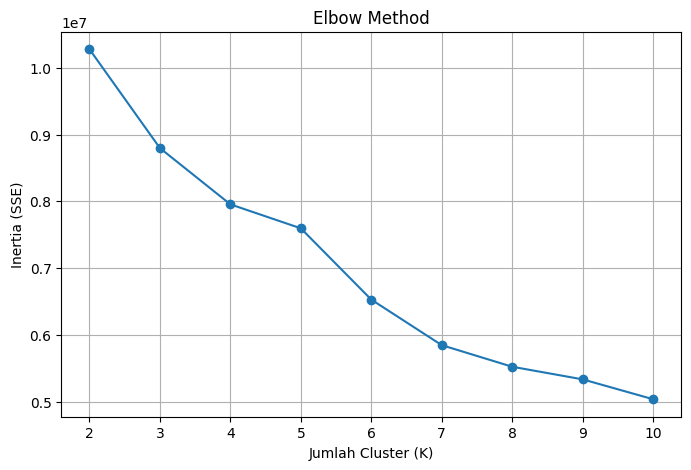

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_df_1["k"],
    results_df_1["inertia"],
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.grid(True)

plt.show()

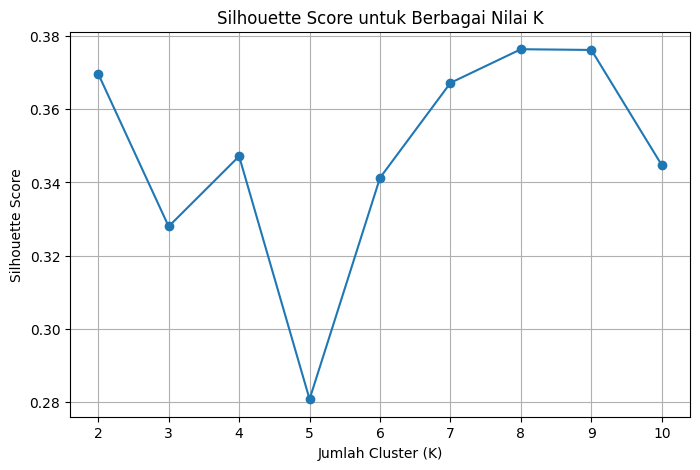

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df_1["k"],
    results_df_1["silhouette"],
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score untuk Berbagai Nilai K")
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# TAHAP 3 — Fit Model K-Means Final
# ============================================================

# Pilih K berdasarkan hasil elbow + silhouette di atas
# (minimal 10 sesuai syarat dosen)
K_OPTIMAL_1 = 8

kmeans_1 = KMeans(
    k=K_OPTIMAL_1,
    seed=42,
    featuresCol="features"
)

model_1 = kmeans_1.fit(data_1)
print(f"✅ Model K-Means selesai dengan K={K_OPTIMAL_1}")
print(f"   Inertia (SSE): {model_1.summary.trainingCost:.2f}")

✅ Model K-Means selesai dengan K=8
   Inertia (SSE): 5524329.80


In [ ]:
# ============================================================
# TAHAP 4 — Transformasi & Distribusi Cluster
# ============================================================

# Gunakan data_full (dengan identifier) agar bisa dianalisis
assembler_1 = VectorAssembler(
    inputCols=feature_cols_1,
    outputCol="features",
    handleInvalid="skip"      # skip baris NaN otomatis
)

data_full_1 = assembler_1.transform(spark_df_1)
clustered_df_1 = model_1.transform(data_full_1)

# Distribusi anggota per cluster
cluster_count_1 = (
    clustered_df_1
    .groupBy("prediction")
    .count()
    .orderBy("prediction")
    .toPandas()
)

print("Distribusi anggota per cluster:")
print(cluster_count_1.to_string(index=False))

Distribusi anggota per cluster:
 prediction  count
          0  98884
          1 183139
          2   9804
          3  64626
          4  18522
          5  57608
          6 152180
          7  79054


In [ ]:
# ============================================================
# VISUALISASI PCA 2D — Sebaran Cluster
# ============================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ambil fitur + label cluster dari clustered_df ke Pandas
viz_pd_1 = (
    clustered_df_1
    .select(*feature_cols_1, "prediction")
    .toPandas()
)

# Pisahkan fitur dan label
X_viz_1 = viz_pd_1[feature_cols_1].fillna(viz_pd_1[feature_cols_1].median())
y_viz_1 = viz_pd_1["prediction"]

# Reduksi ke 2 komponen untuk plotting
pca_2d_1 = PCA(n_components=2, random_state=42)
X_2d_1   = pca_2d_1.fit_transform(X_viz_1)

explained_1 = pca_2d_1.explained_variance_ratio_ * 100
print(f"Variance explained — PC1: {explained_1[0]:.2f}% | PC2: {explained_1[1]:.2f}% | Total: {explained_1.sum():.2f}%")

Variance explained — PC1: 35.96% | PC2: 16.50% | Total: 52.45%


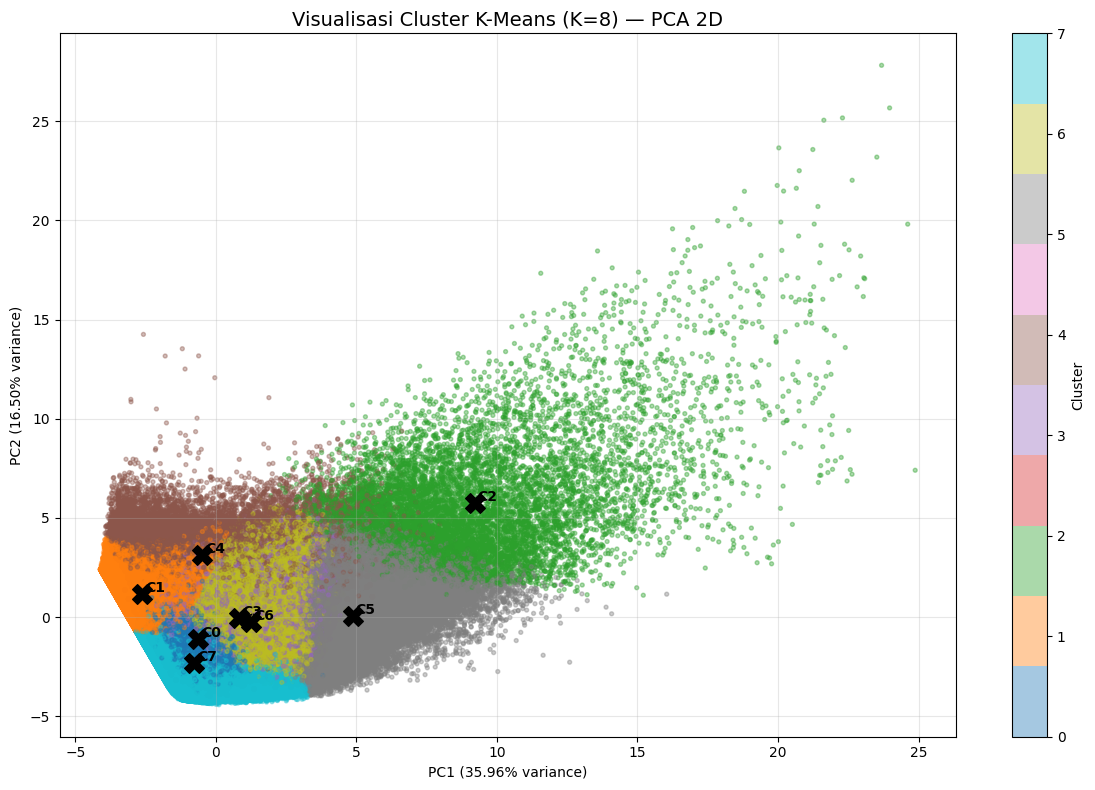

In [ ]:
# Plot
fig_1, ax_1 = plt.subplots(figsize=(12, 8))

scatter_1 = ax_1.scatter(
    X_2d_1[:, 0],
    X_2d_1[:, 1],
    c=y_viz_1,
    cmap="tab10",
    alpha=0.4,
    s=8
)

# Tambahkan centroid tiap cluster
for cluster_id in sorted(y_viz_1.unique()):
    mask = y_viz_1 == cluster_id
    cx_1, cy_1 = X_2d_1[mask, 0].mean(), X_2d_1[mask, 1].mean()
    ax_1.scatter(cx_1, cy_1, s=200, c="black", marker="X", zorder=5)
    ax_1.annotate(
        f"C{cluster_id}",
        xy=(cx_1, cy_1),
        xytext=(cx_1 + 0.1, cy_1 + 0.1),
        fontsize=10,
        fontweight="bold",
        color="black"
    )

plt.colorbar(scatter_1, label="Cluster")
ax_1.set_title(f"Visualisasi Cluster K-Means (K={K_OPTIMAL_1}) — PCA 2D", fontsize=14)
ax_1.set_xlabel(f"PC1 ({explained_1[0]:.2f}% variance)")
ax_1.set_ylabel(f"PC2 ({explained_1[1]:.2f}% variance)")
ax_1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== PROFIL RATA-RATA PER CLUSTER (K=8) ===
prediction                        0         1         2         3         4         5         6         7
avg_rank                   0.006919  0.919472  0.072182  0.241196  0.365616 -0.907545 -0.174872 -1.432548
best_rank_observed        -0.287738  1.212863 -0.777196  0.039956  0.300351 -1.114719 -0.529718 -0.624463
worst_rank_observed        0.204228  0.108950  0.716839  0.334683  0.183185  0.410240  0.492771 -2.160814
peak_rank                 -0.227215  1.282032 -0.743909 -0.598488  0.305399 -1.063491 -0.437910 -0.557858
avg_rank_change           -1.759918  0.376677  0.400659  0.147237  0.436503  0.371315  0.224434  0.353810
best_rank_jump            -1.015917  0.836167 -1.342577 -0.144508  0.014408 -0.608832 -0.400508  0.829569
avg_track_age_days        -0.230704 -0.112168  0.882453 -0.110429  4.887214 -0.112795 -0.163536 -0.218786
max_track_age_days        -0.253273 -0.134876  1.170665 -0.107447  4.834255 -0.022341 -0.157281 -0.241680
fir

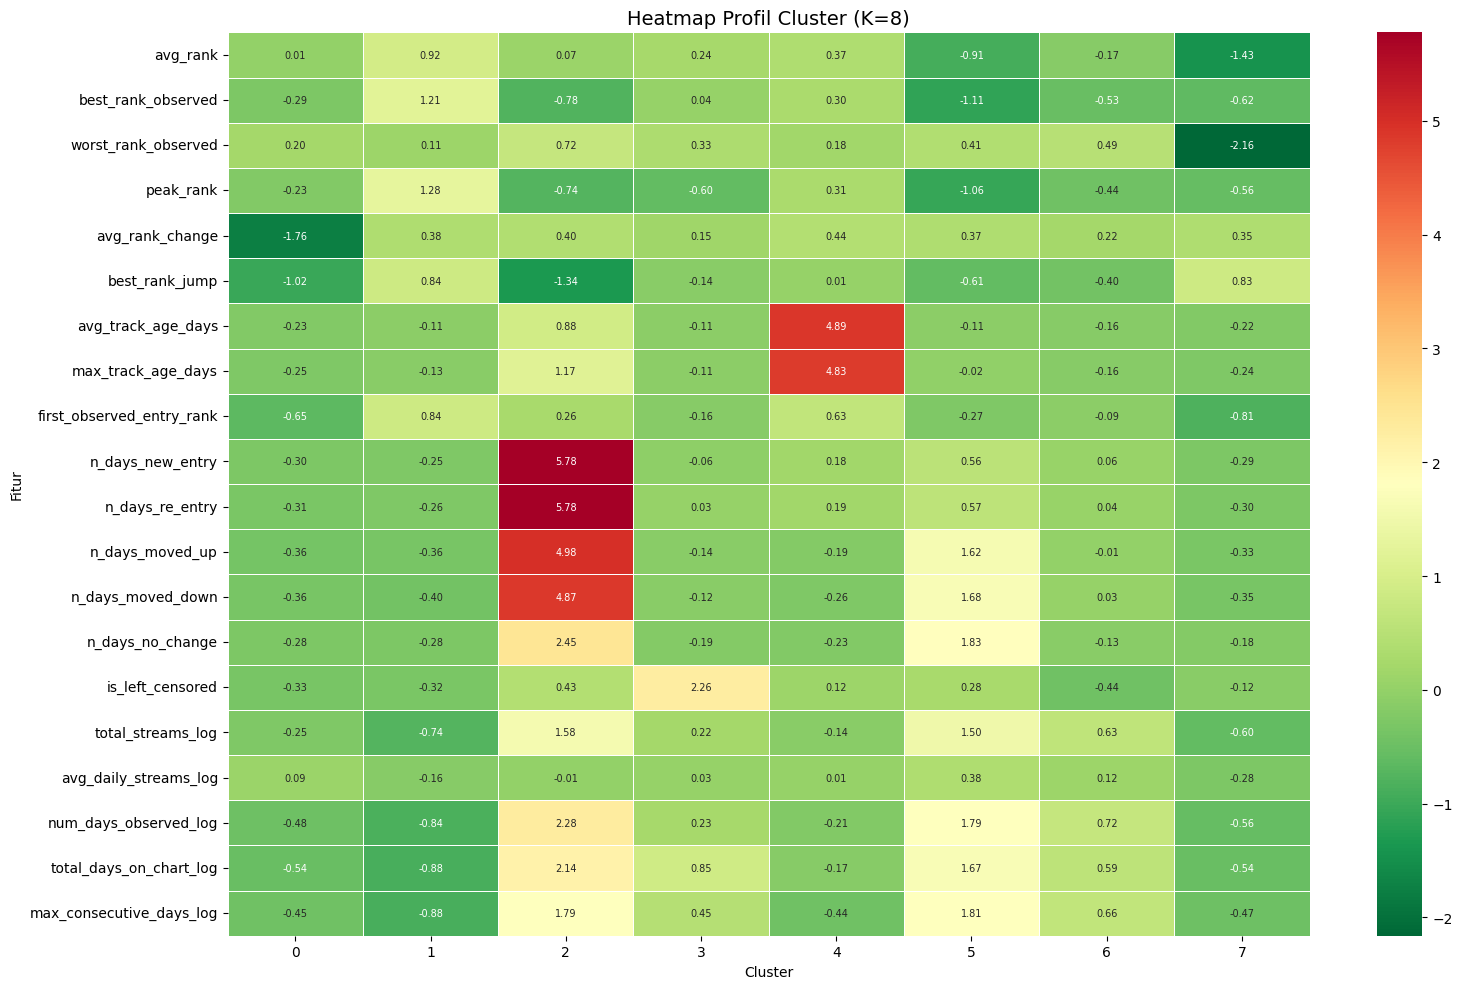

In [ ]:
 # ============================================================
# TAMBAHAN — Profil Rata-rata per Cluster untuk Model K=8
# ============================================================
from pyspark.sql.functions import avg, col

cluster_profile_1 = (
    clustered_df_1
    .groupBy("prediction")
    .agg(*[avg(col(c)).alias(c) for c in feature_cols_1])
    .orderBy("prediction")
)

cluster_profile_pd_1 = cluster_profile_1.toPandas().set_index("prediction")

print("=== PROFIL RATA-RATA PER CLUSTER (K=8) ===")
print(cluster_profile_pd_1.T.to_string())

# (opsional) heatmap-nya juga, biar enak dilihat
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))
sns.heatmap(
    cluster_profile_pd_1.T,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Heatmap Profil Cluster (K=8)", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()